# Cycles room trajectories

Visualize pre-generated animal trajectories for all 20 cycles rooms (`data/cycles/`).

1. **Overview** — full path of trajectory 0 per room (10×2 grid), line colored linearly by trajectory timestep.
2. **First 6 seconds** — one panel per second (s = 0 … 5) for each room (20 rows × 6 columns); each point is a dot colored by the **sum of WSM inputs** at that timestep (RAE sensory input before masking).


In [ ]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

for _path in (Path.cwd(), *Path.cwd().parents):
    if (_path / "pyproject.toml").is_file():
        _root = str(_path)
        if _root not in sys.path:
            sys.path.insert(0, _root)
        break
else:
    raise RuntimeError("Could not find project root (pyproject.toml)")

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

from experiments.old_cycles.cycles_data import load_manifest, load_room
from experiments.old_cycles.cycles_paths import ROOMS_DIR
from experiments.old_cycles.cycles_train import CyclesConfig

manifest = load_manifest()
dt_s = manifest.dt_s
steps_per_second = int(round(1.0 / dt_s))
traj_index = 0  # first of manifest.n_trajectories parallel walks

print(f"Room data: {ROOMS_DIR.resolve()}")
print(
    f"Rooms: {manifest.n_rooms}, dt={dt_s}s, "
    f"steps/s={steps_per_second}, speed={manifest.speed!r}"
)


Room data: /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/data/cycles
Rooms: 20, dt=0.05s, steps/s=20, speed='slow'


In [2]:
MASK_RATE = CyclesConfig().mask_rate


def load_all_rooms(manifest):
    """Load arena map, WSM, and trajectories for every room in the manifest."""
    rooms = []
    for spec in manifest.rooms:
        arena_map, traj_coord, wsm, room_spec = load_room(spec, manifest=manifest)
        rooms.append(
            {
                "spec": room_spec,
                "arena_map": arena_map,
                "traj_coord": traj_coord,
                "wsm": wsm,
            }
        )
    return rooms


def slice_second(traj_coord, second: int, *, steps_per_second: int) -> np.ndarray:
    """Trajectory coords for ``[second, second + 1)`` in seconds."""
    start = second * steps_per_second
    end = start + steps_per_second
    return traj_coord[start:end]


def rae_wsm_input(wsm, coords: np.ndarray) -> np.ndarray:
    """WSM sensory vectors at trajectory points, shape ``(T, n_wsm_cells)``."""
    return wsm.get_response(coords[np.newaxis, ...])[0]


def wsm_input_sum(wsm, coords: np.ndarray) -> np.ndarray:
    """Sum of RAE WSM input activations at each timestep."""
    return rae_wsm_input(wsm, coords).sum(axis=-1)


def _style_arena_ax(ax, arena_map: np.ndarray, *, title: str | None = None) -> None:
    ax.imshow(arena_map, cmap="gray_r", origin="upper", vmin=0, vmax=1, interpolation="nearest")
    ax.set_xlim(-0.5, arena_map.shape[1] - 0.5)
    ax.set_ylim(arena_map.shape[0] - 0.5, -0.5)
    ax.set_aspect("equal")
    ax.axis("off")
    if title is not None:
        ax.set_title(title, fontsize=8)


def global_wsm_sum_range(
    rooms,
    traj_index: int,
    *,
    steps_per_second: int,
    n_seconds: int = 6,
) -> tuple[float, float]:
    """Shared WSM-sum color limits for the first ``n_seconds`` of each walk."""
    n_steps = n_seconds * steps_per_second
    vmin, vmax = np.inf, -np.inf
    for room in rooms:
        coords = room["traj_coord"][traj_index, :n_steps]
        totals = wsm_input_sum(room["wsm"], coords)
        vmin = min(vmin, float(totals.min()))
        vmax = max(vmax, float(totals.max()))
    return vmin, vmax


def plot_trajectory_by_time(
    ax,
    arena_map: np.ndarray,
    coords: np.ndarray,
    *,
    title: str | None = None,
    linewidth: float = 0.6,
    alpha: float = 0.9,
    cmap: str = "viridis",
) -> LineCollection | None:
    """Line path colored linearly by trajectory timestep index."""
    _style_arena_ax(ax, arena_map, title=title)
    if len(coords) < 2:
        return None

    xy = np.column_stack([coords[:, 1], coords[:, 0]])
    segments = np.stack([xy[:-1], xy[1:]], axis=1)
    seg_times = np.arange(len(coords) - 1, dtype=float)

    lc = LineCollection(segments, cmap=cmap, linewidth=linewidth, alpha=alpha)
    lc.set_array(seg_times)
    lc.set_clim(0, len(coords) - 1)
    ax.add_collection(lc)
    return lc


def plot_trajectory_wsm_dots(
    ax,
    arena_map: np.ndarray,
    coords: np.ndarray,
    wsm,
    *,
    wsm_vmin: float,
    wsm_vmax: float,
    title: str | None = None,
    marker_size: float = 10.0,
    cmap: str = "viridis",
) -> None:
    """Scatter dots at each timestep, colored by sum of WSM inputs."""
    _style_arena_ax(ax, arena_map, title=title)
    if len(coords) == 0:
        return

    totals = wsm_input_sum(wsm, coords)
    ax.scatter(
        coords[:, 1],
        coords[:, 0],
        c=totals,
        cmap=cmap,
        vmin=wsm_vmin,
        vmax=wsm_vmax,
        s=marker_size,
        linewidths=0,
        zorder=2,
    )


rooms = load_all_rooms(manifest)
assert len(rooms) == manifest.n_rooms
wsm_sum_vmin, wsm_sum_vmax = global_wsm_sum_range(
    rooms, traj_index, steps_per_second=steps_per_second
)
wsm_sum_cmap = ScalarMappable(
    norm=Normalize(vmin=wsm_sum_vmin, vmax=wsm_sum_vmax), cmap="viridis"
)
print(
    f"WSM input sum range, first 6 s (walk #{traj_index}): "
    f"[{wsm_sum_vmin:.2f}, {wsm_sum_vmax:.2f}]"
)
print(f"Training mask_rate={MASK_RATE} (not applied in WSM dot plots)")


WSM input sum range, first 6 s (walk #0): [732.68, 872.22]
Training mask_rate=0.5 (not applied in WSM dot plots)


## Full trajectories (trajectory 0)

One panel per room; each shows the complete 10 min path for the first parallel walk, with line color linear in trajectory timestep (0 → end).


/tmp/ipykernel_296714/1905424672.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


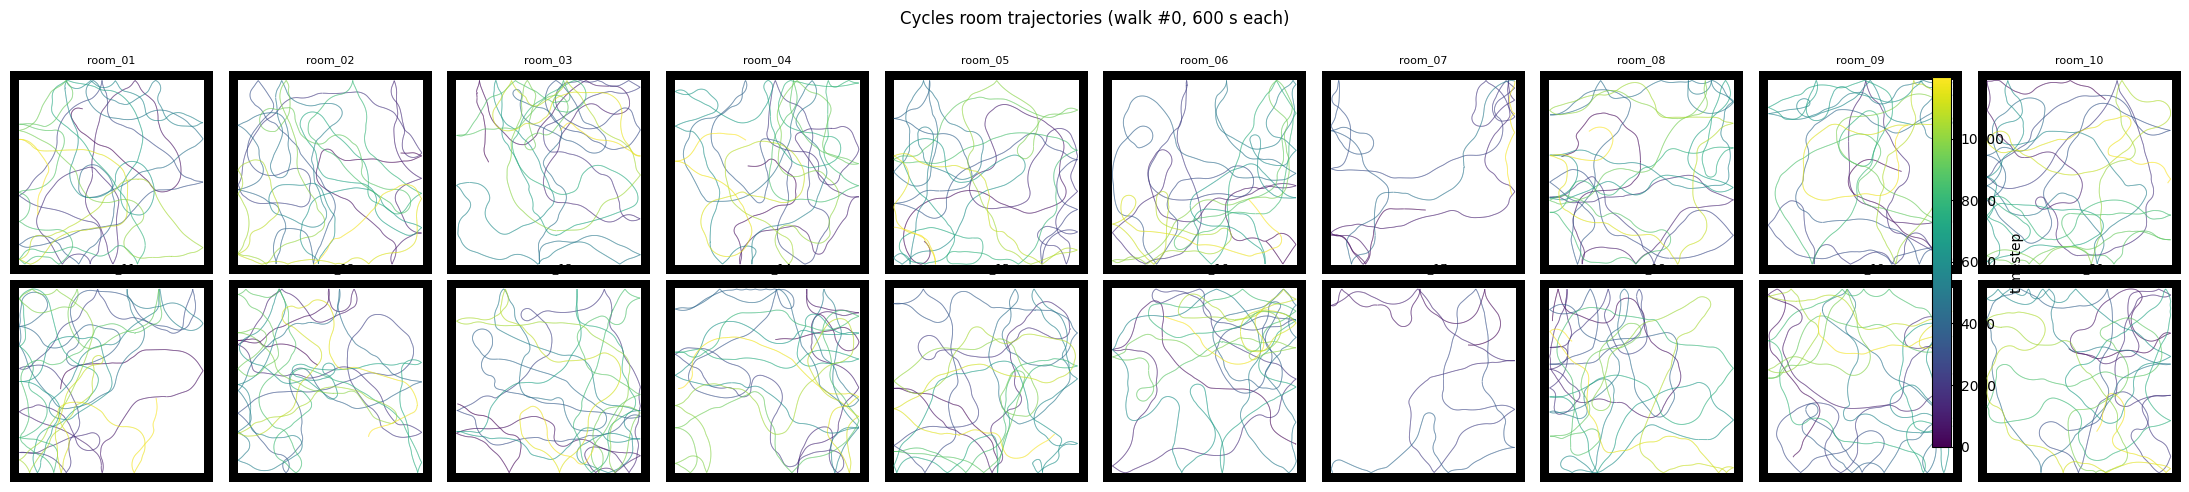

In [3]:
n_cols, n_rows = 10, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.2 * n_cols, 2.4 * n_rows), squeeze=False)

for idx, room in enumerate(rooms):
    row, col = divmod(idx, n_cols)
    ax = axes[row, col]
    traj = room["traj_coord"][traj_index]
    plot_trajectory_by_time(
        ax,
        room["arena_map"],
        traj,
        title=room["spec"].name,
    )

fig.suptitle(
    f"Cycles room trajectories (walk #{traj_index}, {manifest.trial_duration_s:.0f} s each)",
    fontsize=12,
    y=1.02,
)
time_cmap = ScalarMappable(
    norm=Normalize(vmin=0, vmax=manifest.trial_steps - 1), cmap="viridis"
)
cbar = fig.colorbar(
    time_cmap,
    ax=axes.ravel().tolist(),
    fraction=0.025,
    pad=0.02,
)
cbar.set_label("timestep")
fig.tight_layout()
plt.show()


## First 6 seconds (s = 0 … 5)

One row per room; columns are consecutive 1 s windows starting at t = 0 s. Each 50 ms sample is a dot colored by the sum of WSM inputs at that position.


/tmp/ipykernel_296714/1066655769.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


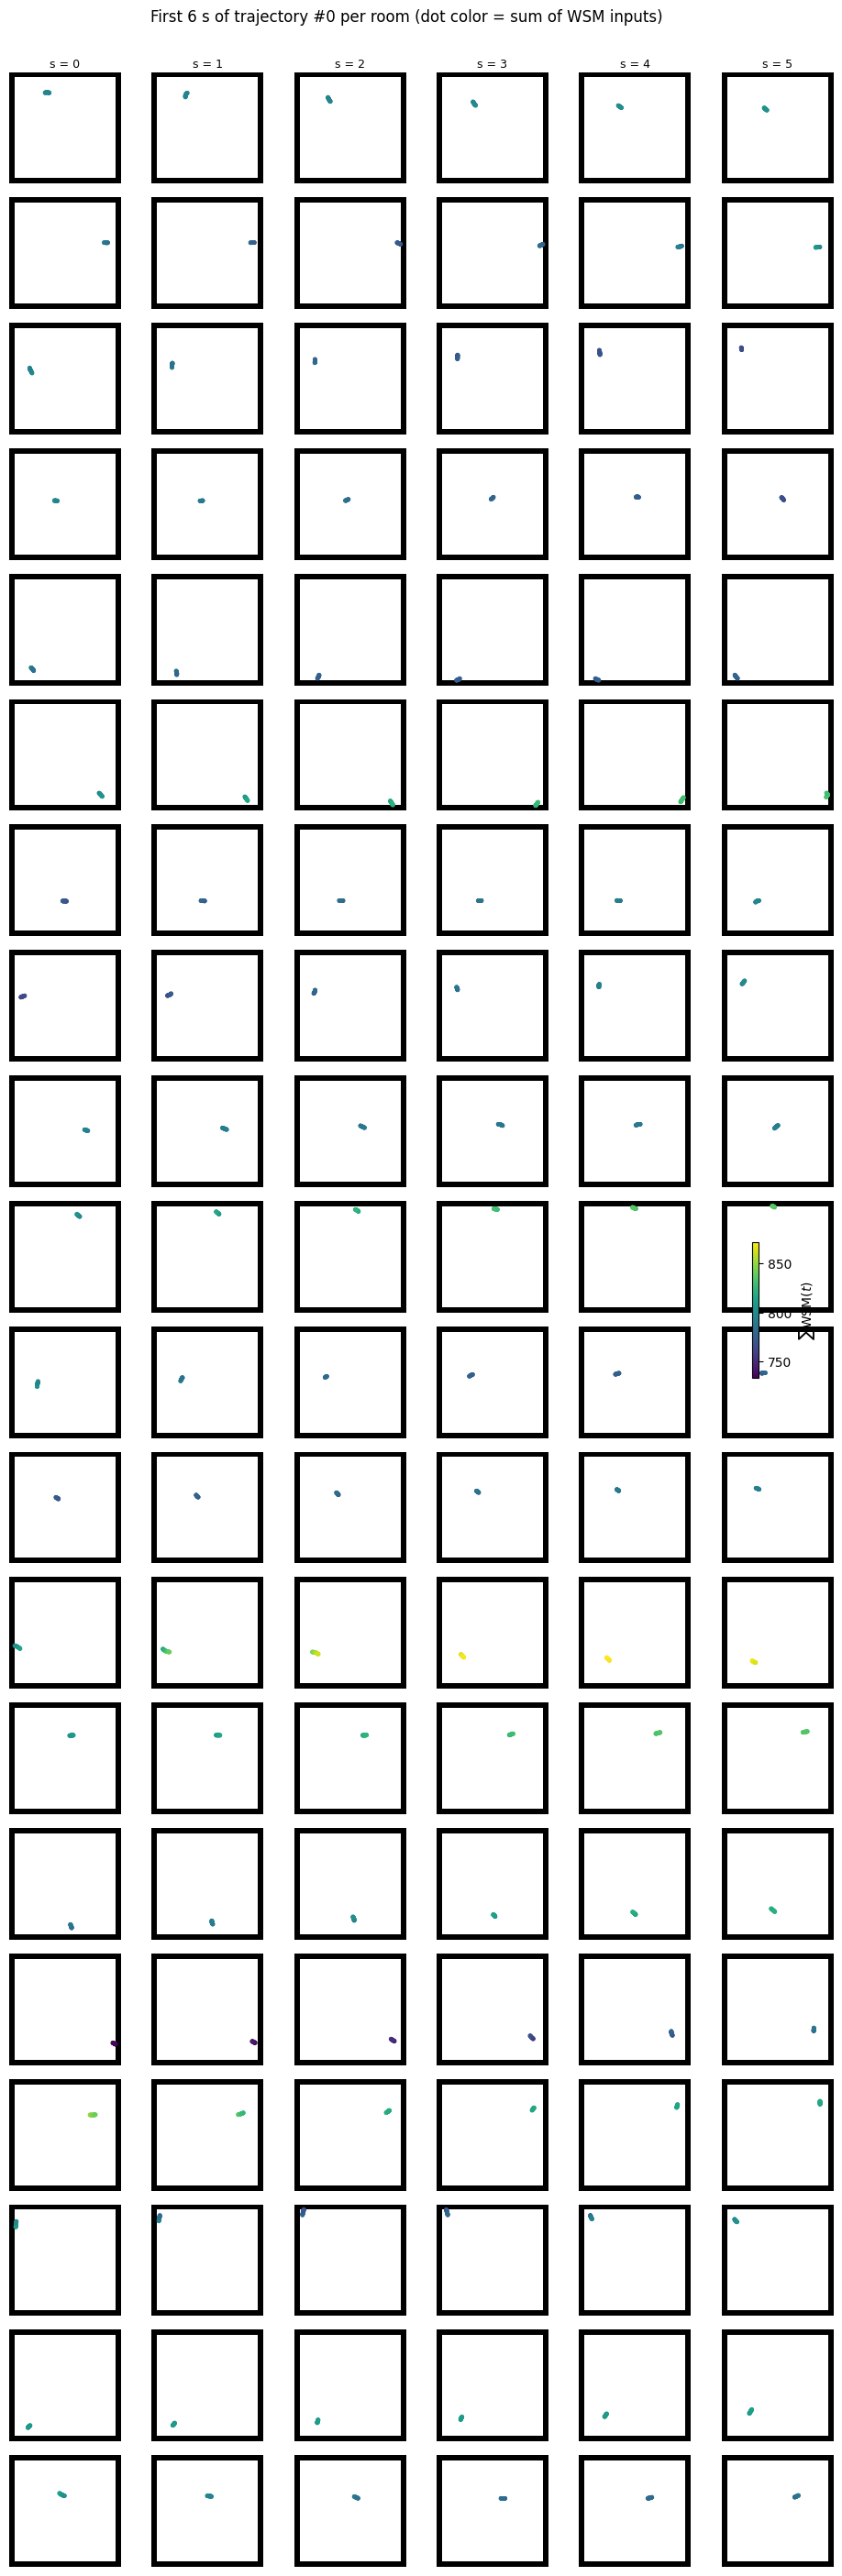

In [4]:
seconds = list(range(6))  # 0, 1, 2, 3, 4, 5
n_room_rows = len(rooms)
n_sec_cols = len(seconds)

fig, axes = plt.subplots(
    n_room_rows,
    n_sec_cols,
    figsize=(1.6 * n_sec_cols, 1.4 * n_room_rows),
    squeeze=False,
)

for row, room in enumerate(rooms):
    traj = room["traj_coord"][traj_index]
    for col, sec in enumerate(seconds):
        ax = axes[row, col]
        segment = slice_second(traj, sec, steps_per_second=steps_per_second)
        plot_trajectory_wsm_dots(
            ax,
            room["arena_map"],
            segment,
            room["wsm"],
            wsm_vmin=wsm_sum_vmin,
            wsm_vmax=wsm_sum_vmax,
            marker_size=12.0,
        )
        if col == 0:
            ax.set_ylabel(room["spec"].name, fontsize=7, rotation=0, labelpad=28, va="center")

# Column headers
for col, sec in enumerate(seconds):
    axes[0, col].set_title(f"s = {sec}", fontsize=9, pad=4)

fig.suptitle(
    f"First 6 s of trajectory #{traj_index} per room (dot color = sum of WSM inputs)",
    fontsize=12,
    y=1.002,
)
cbar = fig.colorbar(
    wsm_sum_cmap,
    ax=axes.ravel().tolist(),
    fraction=0.01,
    pad=0.01,
)
cbar.set_label(r"$\sum \mathrm{WSM}(t)$")
fig.tight_layout()
plt.show()
